In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
# audio_path = librosa.ex('trumpet')
# y, sr = librosa.load(audio_path)
# print("Audio loaded!")
# print("Sample rate:", sr)
# print("Number of samples:", len(y))

uploaded = files.upload()
filename = list(uploaded.keys())[0]
y, sr = librosa.load(filename)
print("Audio loaded!")
print("Sample rate:", sr)
print("Number of samples:", len(y))
print("Duration:", round(len(y)/sr, 2), "seconds")

Saving Justin Bieber - Sorry (PURPOSE _ The Movement).mp3 to Justin Bieber - Sorry (PURPOSE _ The Movement).mp3
Audio loaded!
Sample rate: 22050
Number of samples: 4525056
Duration: 205.22 seconds


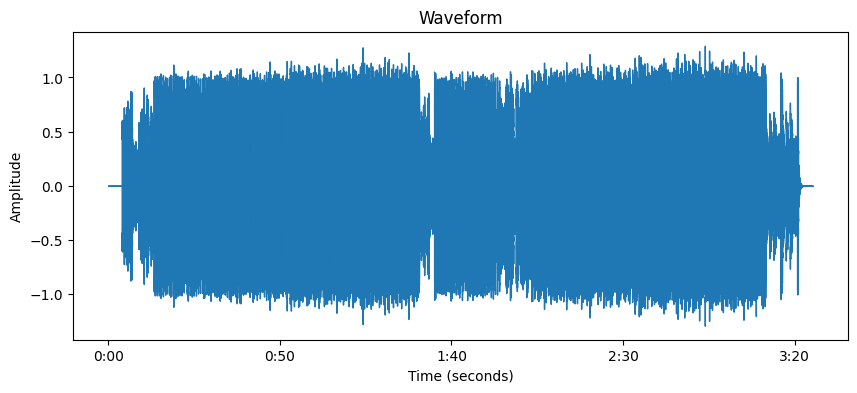

In [ ]:
plt.figure(figsize=(10, 4))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

In [ ]:
# TEMPO
# how fast is the song in beats per minute

tempo, beats = librosa.beat.beat_track(y=y, sr=sr)
print("Estimated tempo:", tempo, "BPM")

Estimated tempo: [135.99917763] BPM


In [ ]:
# MFCCs (Mel-frequency cepstral coefficients)
# Remember how Jeronimo's notebook converted audio from time domain → frequency domain using DFT? MFCCs take that a step further. They describe the texture or timbre of a sound — basically what makes a trumpet sound like a trumpet and not a guitar, even if they're playing the same note.
# For nostalgia, timbre matters a lot — a lo-fi, warm sound feels more nostalgic than a crisp digital one.

mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
print("MFCCs shape:", mfccs.shape)

# 230/5.3 => divided into 43.3962264151 chunks per second with 13 rows of numbers/fingerprint

mfccs_mean = np.mean(mfccs, axis=1)
print("MFCC means:", mfccs_mean)

MFCCs shape: (13, 8839)
MFCC means: [-56.895588   101.16608      2.1991389   10.889723     6.4127145
   0.80336106  -2.700393     3.6258566   -3.5030866    6.4607096
  -0.20633018   6.300143    -0.7065526 ]


In [ ]:
# Chroma
# This one is more intuitive. Chroma captures the harmonic and melodic content of a song — basically which of the 12 musical notes (C, C#, D, D#... B) are most prominent.
# For nostalgia this matters because certain chord qualities — like minor keys — tend to feel more emotional and nostalgic. Think of sad 90s ballads.

chroma = librosa.feature.chroma_stft(y=y, sr=sr)
chroma_mean = np.mean(chroma, axis=1)
print("Chroma shape:", chroma.shape)
print("Chroma means:", chroma_mean)


Chroma shape: (12, 8839)
Chroma means: [0.39648795 0.32503438 0.3698841  0.4317053  0.3339818  0.49701557
 0.33108503 0.37089542 0.34075695 0.32323518 0.4657842  0.35410327]


In [ ]:
# Feature 4: Spectral Centroid
# Last one. This measures the "brightness" of the sound — where the "center of mass" of the frequencies sits. A high spectral centroid means the sound is bright and sharp (think modern pop). A low one means it's warm and dark (think old vinyl recordings).
# For nostalgia, older recordings tend to have lower spectral centroids — that warm, slightly muffled quality.

spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
spectral_centroid_mean = np.mean(spectral_centroid)
print("Spectral centroid mean:", spectral_centroid_mean)

Spectral centroid mean: 2066.455999824899


In [ ]:
features = {
    "tempo": float(tempo[0]),
    "mfccs": mfccs_mean.tolist(),
    "chroma": chroma_mean.tolist(),
    "spectral_centroid": spectral_centroid_mean
}

print("=== Audio Features ===")
print(f"Tempo: {features['tempo']} BPM")
print(f"MFCCs (13 values): {[round(x, 2) for x in features['mfccs']]}")
print(f"Chroma (12 values): {[round(x, 2) for x in features['chroma']]}")
print(f"Spectral Centroid: {round(features['spectral_centroid'], 2)} Hz")

=== Audio Features ===
Tempo: 135.99917763157896 BPM
MFCCs (13 values): [-56.9, 101.17, 2.2, 10.89, 6.41, 0.8, -2.7, 3.63, -3.5, 6.46, -0.21, 6.3, -0.71]
Chroma (12 values): [0.4, 0.33, 0.37, 0.43, 0.33, 0.5, 0.33, 0.37, 0.34, 0.32, 0.47, 0.35]
Spectral Centroid: 2066.46 Hz


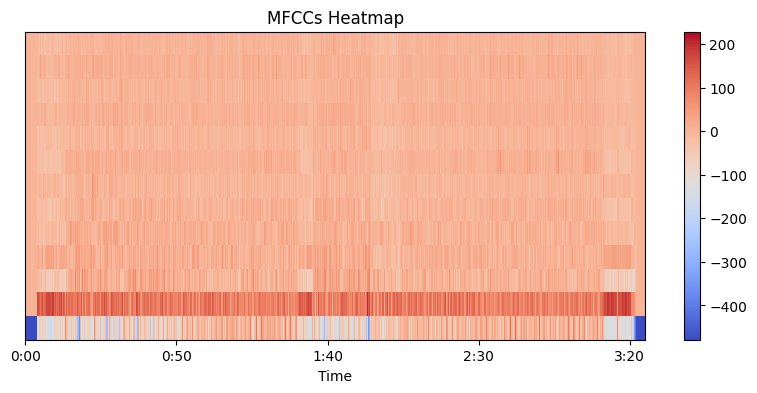

In [ ]:
plt.figure(figsize=(10, 4))
librosa.display.specshow(mfccs, x_axis='time', sr=sr)
plt.colorbar()
plt.title("MFCCs Heatmap")
plt.show()

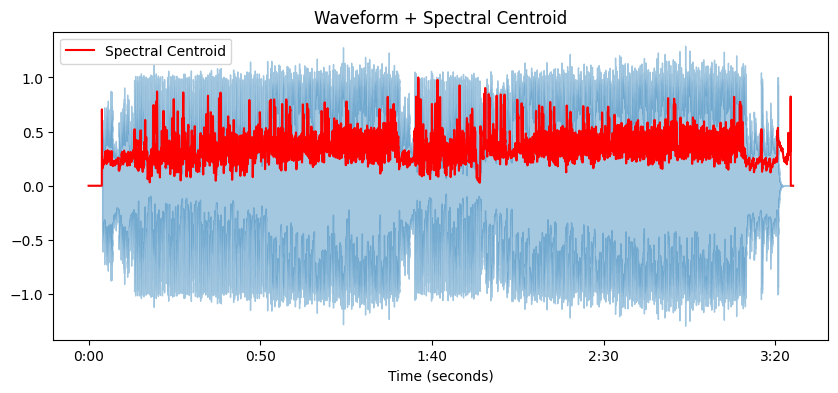

In [ ]:
times = librosa.times_like(spectral_centroid, sr=sr)

plt.figure(figsize=(10, 4))
librosa.display.waveshow(y, sr=sr, alpha=0.4)
plt.plot(times, spectral_centroid[0] / np.max(spectral_centroid), color='r', label='Spectral Centroid')
plt.title("Waveform + Spectral Centroid")
plt.xlabel("Time (seconds)")
plt.legend()
plt.show()